<a href="https://colab.research.google.com/github/schenbus0/matematicky_software_zapocet/blob/main/msw_zapocet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uloha 1: Linearni a nelinearni oscilatory

A) Linearni oscilator

Slabe, kriticke a silne tlumeni:

Slabe tlumeni: System vykonava tlumene kmity, jeho vychylka opakovane prochazi nulou, ale amplituda exponencialne klesa.

Kriticke tlumeni: System se vrati do rovnovazne polohy v nejkratsim moznem case a zcela bez oscilaci (prekmitu).

Silne tlumeni: System je pretlumeny, neosciluje a navrat do rovnovahy trva velmi dlouho (pohyb v extremne viskoznim prostredi).

Zmena tlumeni o nekolik procent: Prechod mezi rezimy je plynuly z hlediska matematickych korenu, ale z pohledu chovani systemu je v bode kritickeho tlumeni kvalitativne ostry (prekmit bud nastane, nebo nenastane).

Mechanismus rezonance: K rezonanci dochazi, pokud se frekvence vnejsiho buzeni shoduje nebo blizi vlastni prirodni frekvenci oscilatoru. Vnejsi sila dodava energii systemu presne ve fazi s jeho pohybem, coz zpusobuje masivni narust amplitudy.

Symbolicka matematika: Ano, linearni diferencialni rovnice s konstantnimi koeficienty lze resit analyticky (symbolicky). V Pythonu k tomu slouzi knihovna SymPy a jeji funkce dsolve().

B) Duffinguv oscilator

Chaoticke chovani: Pro doporucene parametry (delta=0.2, alpha=-1, beta=1, gamma=0.3, omega=1.2) v modelu dochazi k chaotickemu chovani. System vykazuje extremni citlivost na pocatecni podminky.

Mala vs. velka pocatecni podminka: Jelikoz je koeficient alpha = -1, potencial systemu ma tvar dvou studni. Mala pocatecni podminka drzi oscilator uzamceny v jedne ze studni. Velka pocatecni podminka doda dostatek energie k tomu, aby system zacal chaoticky preskakovat barieru mezi obema studnami.

Zvyseni buzeni gamma a pocet atraktoru: Se zvysovanim parametru buzeni dochazi k bifurkacim (zdvojovani periody). Pocet atraktoru a jejich struktura se dynamicky meni, system strida chaoticke rezimy s okny stability.

C) Van der Poluv oscilator

Tvar limitniho cyklu (mu=1 -> mu=10): Pri mu=1 je limitni cyklus hladky a blizky elipse. Pri prechodu na mu=10 se meni na ostre lomeny tvar, ktery odpovida silne nelinearnimu rezimu.

Rychle skoky a pomale faze: Tento jev zpusobuji relaxacni oscilace. Nelinearni tlumeni meni sve znamenko v zavislosti na poloze. Pro |x| vetsi nez 1 (absolutni hodnota) system energii tlumi (pomala faze), zatimco pro |x| mensi nez 1 se tlumeni stava zapornym a do systemu energii pumpuje, coz vyvola prudky, rychly skok.

Vliv pocatecnich podmineky a pocet atraktoru: Model ma pouze jeden stabilni atraktor (limitni cyklus). Pocatecni podminky ovlivni pouze pocatecni prechodovy dej, ale po delsim case vsechny trajektorie skonci na identickem limitnim cyklu.

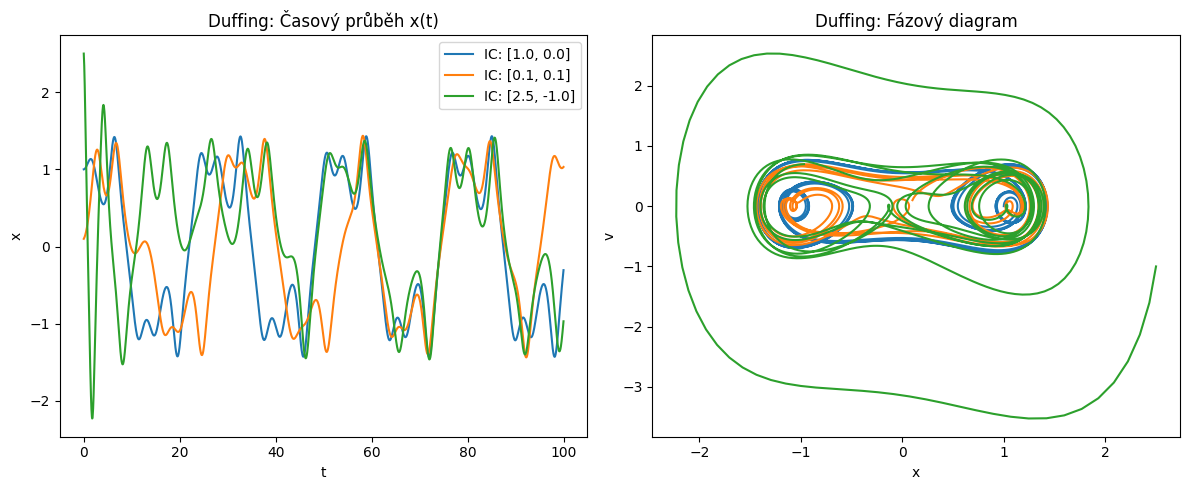

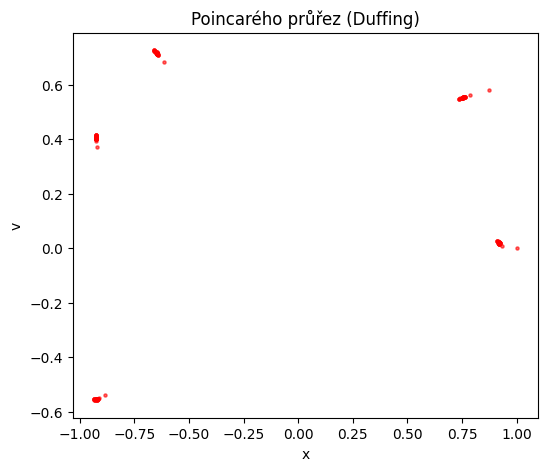

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Definice systémů (přepis na soustavy 2 ODE)

def linear_oscillator(t, y, omega0, delta):
    """
    Lineární tlumený oscilátor: x'' + 2*delta*x' + omega0^2 * x = 0
    y = [x, v]
    """
    x, v = y
    dxdt = v
    dvdt = -2 * delta * v - (omega0**2) * x
    return [dxdt, dvdt]

def duffing_oscillator(t, y, delta, alpha, beta, gamma, omega):
    """
    Duffingův oscilátor: x'' + delta*x' + alpha*x + beta*x^3 = gamma*cos(omega*t)
    """
    x, v = y
    dxdt = v
    dvdt = -delta * v - alpha * x - beta * (x**3) + gamma * np.cos(omega * t)
    return [dxdt, dvdt]

def vanderpol_oscillator(t, y, mu):
    """
    Van der Polův oscilátor: x'' - mu*(1 - x^2)*x' + x = 0
    """
    x, v = y
    dxdt = v
    dvdt = mu * (1 - x**2) * v - x
    return [dxdt, dvdt]

# 2. Simulace a vykreslení

t_span = (0, 100)
t_eval = np.linspace(0, 100, 2000)
ics = [[1.0, 0.0], [0.1, 0.1], [2.5, -1.0]] # Různé počáteční podmínky

# --- VIZUALIZACE DUFFINGOVA OSCILÁTORU ---
delta, alpha, beta, gamma, omega = 0.2, -1.0, 1.0, 0.3, 1.2

plt.figure(figsize=(12, 5))
for ic in ics:
    sol = solve_ivp(duffing_oscillator, t_span, ic, args=(delta, alpha, beta, gamma, omega), t_eval=t_eval)
    plt.subplot(1, 2, 1)
    plt.plot(sol.t, sol.y[0], label=f"IC: {ic}")
    plt.subplot(1, 2, 2)
    plt.plot(sol.y[0], sol.y[1])

plt.subplot(1, 2, 1)
plt.title("Duffing: Časový průběh x(t)")
plt.xlabel("t"); plt.ylabel("x"); plt.legend()
plt.subplot(1, 2, 2)
plt.title("Duffing: Fázový diagram")
plt.xlabel("x"); plt.ylabel("v")
plt.tight_layout()
plt.show()

# --- POINCARÉHO PRŮŘEZ PRO DUFFINGA ---
# Vzorkování v čase t = n * T, kde T = 2*pi / omega
T = 2 * np.pi / omega
t_poincare = np.arange(0, 1000, T) # Delší čas pro lepší zobrazení atraktoru
sol_p = solve_ivp(duffing_oscillator, (0, 1000), [1.0, 0.0], args=(delta, alpha, beta, gamma, omega), t_eval=t_poincare)

plt.figure(figsize=(6, 5))
plt.scatter(sol_p.y[0], sol_p.y[1], s=5, color='red', alpha=0.6)
plt.title("Poincarého průřez (Duffing)")
plt.xlabel("x")
plt.ylabel("v")
plt.show()

Uloha 2: Programova implementace SIR modelu

Model simuluje sireni peti infekcnich nemoci s konstantni incidenci v populaci o velikosti 100 000 jedincu.

Vrchol epidemie: U vysoce infekcnich nemoci (napr. spalnicky s vysokym reprodukcnim cislem R0) nastava vrchol epidemie velmi brzy (v radu dnu az tydnu) a ma velmi ostry prubeh. U nemoci s nizkym R0 (napr. chripka) je vrchol posunuty dal v case a je vyrazne plossi.

Doba trvani epidemie: Agresivni epidemie s vysokym R0 projdou populaci velmi rychle, protoze v kratkem case dojde k vycerpani nachylnych jedincu (S). Mene nakazlive nemoci se v populaci drzi podstatne delsi dobu.

Konecna bilance: U spalnicek nebo nestovic nakonec onemocni temer cela populace (krivka nachylnych S klesa k nule). U chripky podstatna cast populace neonemocni vubec, protoze epidemie vyhasne drive diky dosazeni kolektivni imunity.

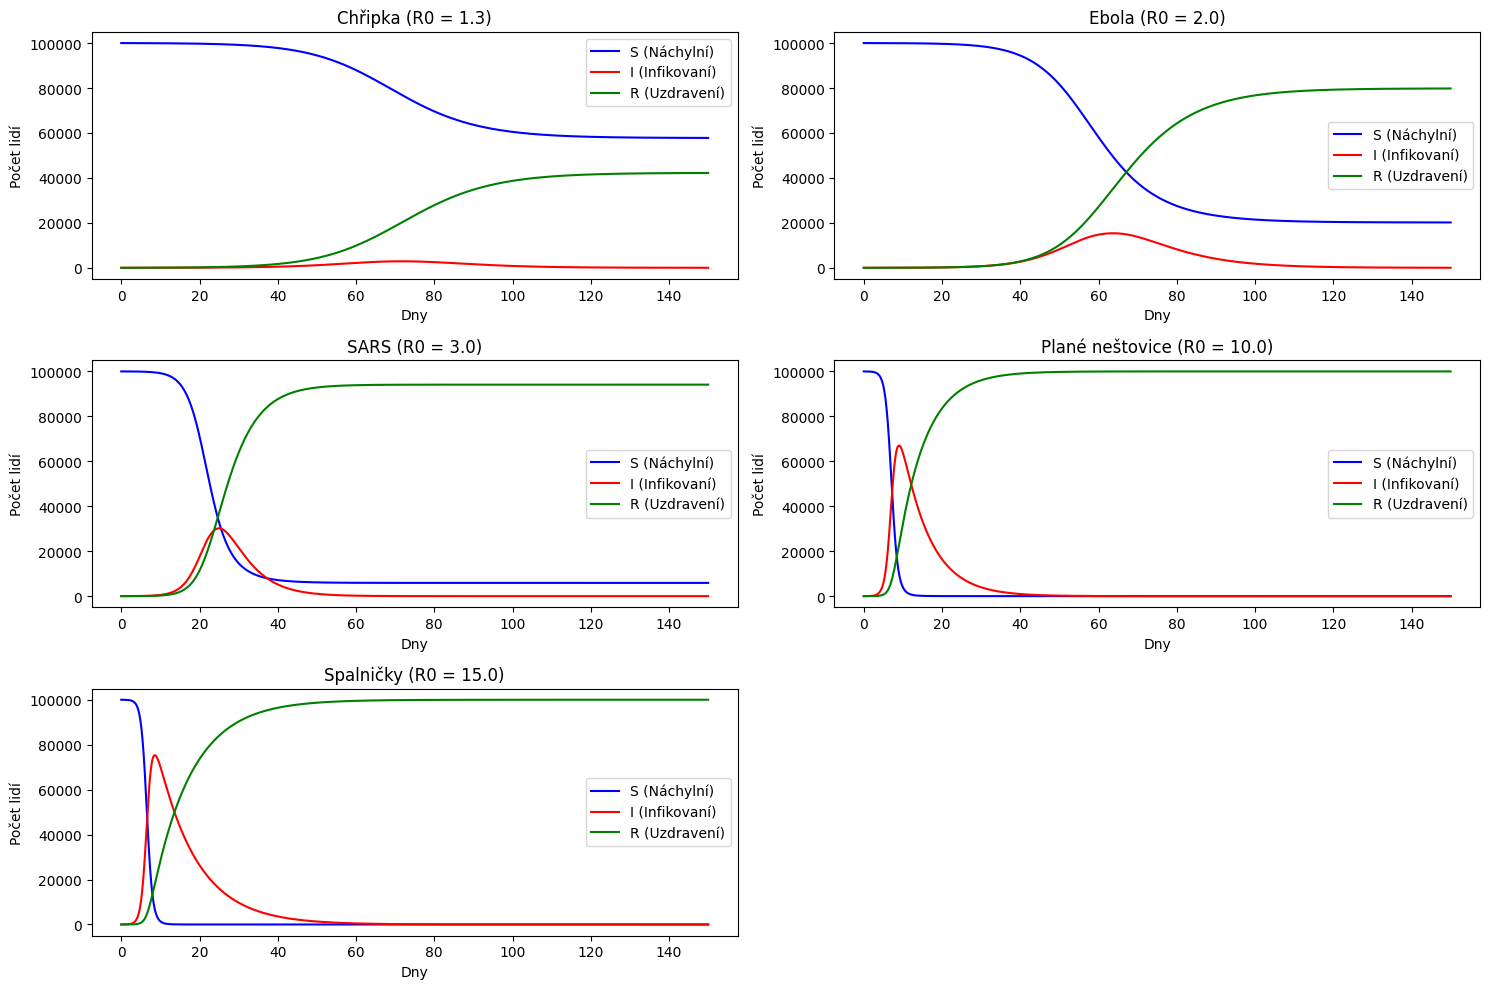

In [5]:
# Definice SIR modelu
def sir_model(t, y, beta, gamma):
    S, I, R = y
    N = S + I + R
    dSdt = - (beta * S * I) / N
    dIdt = (beta * S * I) / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Příklad parametrů pro 5 nemocí (odhadovaná R0 = beta / gamma)
# Předpokládáme dobu infekčnosti (1/gamma). Pak beta = R0 * gamma.
diseases = {
    "Chřipka":      {"R0": 1.3, "duration": 3},
    "Ebola":        {"R0": 2.0, "duration": 7},
    "SARS":         {"R0": 3.0, "duration": 5},
    "Plané neštovice":{"R0": 10.0, "duration": 7},
    "Spalničky":    {"R0": 15.0, "duration": 10}
}

N = 100000  # Celková populace
I0 = 10     # Počáteční počet nakažených
S0 = N - I0
R0_pop = 0
y0 = [S0, I0, R0_pop]
t_span = (0, 150)
t_eval = np.linspace(0, 150, 1000)

# Simulace a vykreslení pro všech 5 nemocí
plt.figure(figsize=(15, 10))
for i, (name, params) in enumerate(diseases.items(), 1):
    gamma = 1.0 / params["duration"]
    beta = params["R0"] * gamma

    sol = solve_ivp(sir_model, t_span, y0, args=(beta, gamma), t_eval=t_eval)

    plt.subplot(3, 2, i)
    plt.plot(sol.t, sol.y[0], label="S (Náchylní)", color="blue")
    plt.plot(sol.t, sol.y[1], label="I (Infikovaní)", color="red")
    plt.plot(sol.t, sol.y[2], label="R (Uzdravení)", color="green")
    plt.title(f"{name} (R0 = {params['R0']})")
    plt.xlabel("Dny")
    plt.ylabel("Počet lidí")
    plt.legend()

plt.tight_layout()
plt.show()

Uloha 3: Vytvoreni vlastniho modelu

Zvolena metoda: Soustava obycejnych diferencialnich rovnic (ODE).

Tema: Model dravce a koristi (Lotka-Volterra).

Interpretace: Model simuluje biologicky system vztahu mezi populaci koristi (zajici) a dravcu (lisky). Vysledkem simulace v Jupyter Notebooku jsou stabilni periodicke kmity, kde narust populace koristi vyvola nasledny narust dravcu, coz vede k opetonemu poklesu koristi a naslednemu hladoveni dravcu.

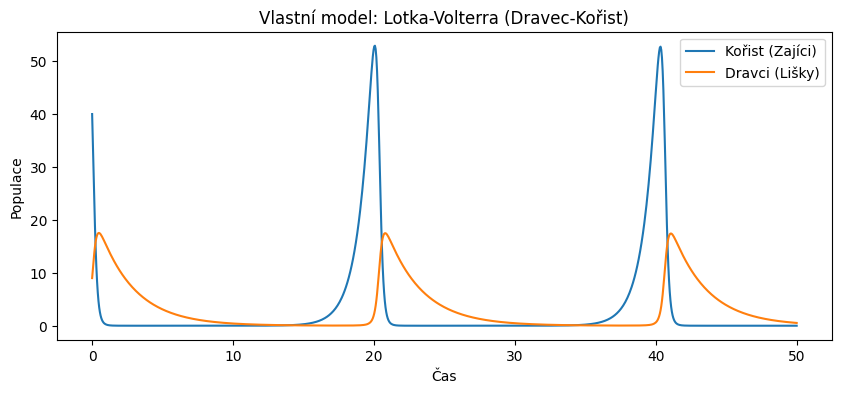

In [6]:
def lotka_volterra(t, y, alpha, beta, delta, gamma):
    x, y = y
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# Parametry: alpha(růst kořisti), beta(lov), delta(růst dravců), gamma(úmrtnost dravců)
sol_lv = solve_ivp(lotka_volterra, (0, 50), [40, 9], args=(1.1, 0.4, 0.1, 0.4), t_eval=np.linspace(0, 50, 1000))

plt.figure(figsize=(10, 4))
plt.plot(sol_lv.t, sol_lv.y[0], label="Kořist (Zajíci)")
plt.plot(sol_lv.t, sol_lv.y[1], label="Dravci (Lišky)")
plt.title("Vlastní model: Lotka-Volterra (Dravec-Kořist)")
plt.xlabel("Čas"); plt.ylabel("Populace"); plt.legend()
plt.show()